In [ ]:
# Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset
import sys

# Jupyter magic command to display plots inline
%matplotlib inline

In [ ]:
# Download the Dataset
# This loads a DatasetDict containing all available splits.

print("Downloading dataset 'carolina-c4ai/carol-domain-sents' from Hugging Face...")
try:
    dataset_dict = load_dataset("carolina-c4ai/carol-domain-sents")
    print(f"Successfully loaded dataset. Found splits: {list(dataset_dict.keys())}")
except Exception as e:
    print(f"Error downloading or loading dataset: {e}", file=sys.stderr)

Successfully loaded dataset. Found splits: ['train', 'test', 'hps']


In [ ]:
# Combine Splits and Convert to DataFrame

print("Converting and combining all dataset splits into a Pandas DataFrame...")

all_dfs = []
for split_name, split_dataset in dataset_dict.items():
    print(f"Processing split: '{split_name}'...")
    all_dfs.append(split_dataset.to_pandas())

# Concatenate all DataFrames from all splits
df = pd.concat(all_dfs, ignore_index=True)

print(f"Successfully combined all splits. Total entries: {len(df)}")

# Check for required columns
required_columns = ['source_typology', 'domain']
if not all(col in df.columns for col in required_columns):
    print(f"Error: The dataset does not contain the required columns ({required_columns}).", file=sys.stderr)
else:
    # Display the first few rows and info of the combined DataFrame
    print("\nDataFrame Info:")
    df.info()
    print("\nDataFrame Head:")
    display(df.head())

Converting and combining all dataset splits into a Pandas DataFrame...
Processing split: 'train'...
Processing split: 'test'...
Processing split: 'hps'...
Successfully combined all splits. Total entries: 4531553

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4531553 entries, 0 to 4531552
Data columns (total 4 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   source_typology    object
 1   carolina_typology  object
 2   domain             object
 3   text               object
dtypes: object(4)
memory usage: 138.3+ MB

DataFrame Head:


,source_typology,carolina_typology,domain,text
0,#NEWS_JOU_W,#DATASETS_AND_OTHER_CORPORA,Journalistic,"Para prosperar, a candidatura de Hamburgo prec..."
1,#DISCUSSION_VIR_W,#WIKIS,Virtual,Acreditando tratar-se da força de Antônio Nett...
2,#VOCABULARY_ENTRY_INS_W,#WIKIS,Instructional,"Iniciou-se como escritora ao publicar ""13 Cont..."
3,#USER_PAGE_VIR_W,#WIKIS,Virtual,"Chegando a Santa Maria, podemos visitar o camp..."
4,#USER_PAGE_VIR_W,#WIKIS,Virtual,"Além disto, e considerando o alto grau de frag..."


In [ ]:
# Analysis of Association between Columns
print("="*60)
print(" Analysis: Association between 'source_typology' and 'domain'")
print("="*60)
try:
    # First, print the total number of distinct typologies
    total_unique_typologies = df['source_typology'].nunique()
    print(f"Total distinct 'source_typology' values: {total_unique_typologies}\n")

    # Group by 'source_typology' and find all unique 'domain' values associated with it
    associations = df.groupby('source_typology')['domain'].unique()
    
    if associations.empty:
        print("Could not find data for 'source_typology'.")
    else:
        # Convert the resulting Series into a DataFrame for compact display
        # The index (source_typology) becomes a column, and the values (domain lists)
        # are named 'associated_domains'
        associations_df = associations.reset_index(name='associated_domains')
        
        print("DataFrame of 'source_typology' and its associated 'domain'(s):")
        display(associations_df)
            
except KeyError:
    print("Critical Error: Failed to group data. Check column names.", file=sys.stderr)

 Analysis: Association between 'source_typology' and 'domain'
Total distinct 'source_typology' values: 32

DataFrame of 'source_typology' and its associated 'domain'(s):


,source_typology,associated_domains
0,#,[Juridical]
1,#ACTIVITIES_ORGANIZATION_AND_EXPERIENCES_SHARI...,[Virtual]
2,#APPELLATE_DECISION_RECORDS_JUR_W,[Juridical]
3,#ARTICLE_JOU_W,[Journalistic]
4,#BIOGRAPHY_JUR_W,[Juridical]
5,#CONSTITUTION_ANNOTATED_JUD_W,[Juridical]
6,#COURT_MEMBERS_INFORMATION_JUD_W,[Juridical]
7,#DISCUSSION_VIR_W,[Virtual]
8,#EDUCATIONAL_RESOURCES_INS_W,[Instructional]
9,#FAQ_VIR_W,[Virtual]



Generating distribution plot (Countplot) for 'source_typology'...


/tmp/ipykernel_16761/3867573108.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


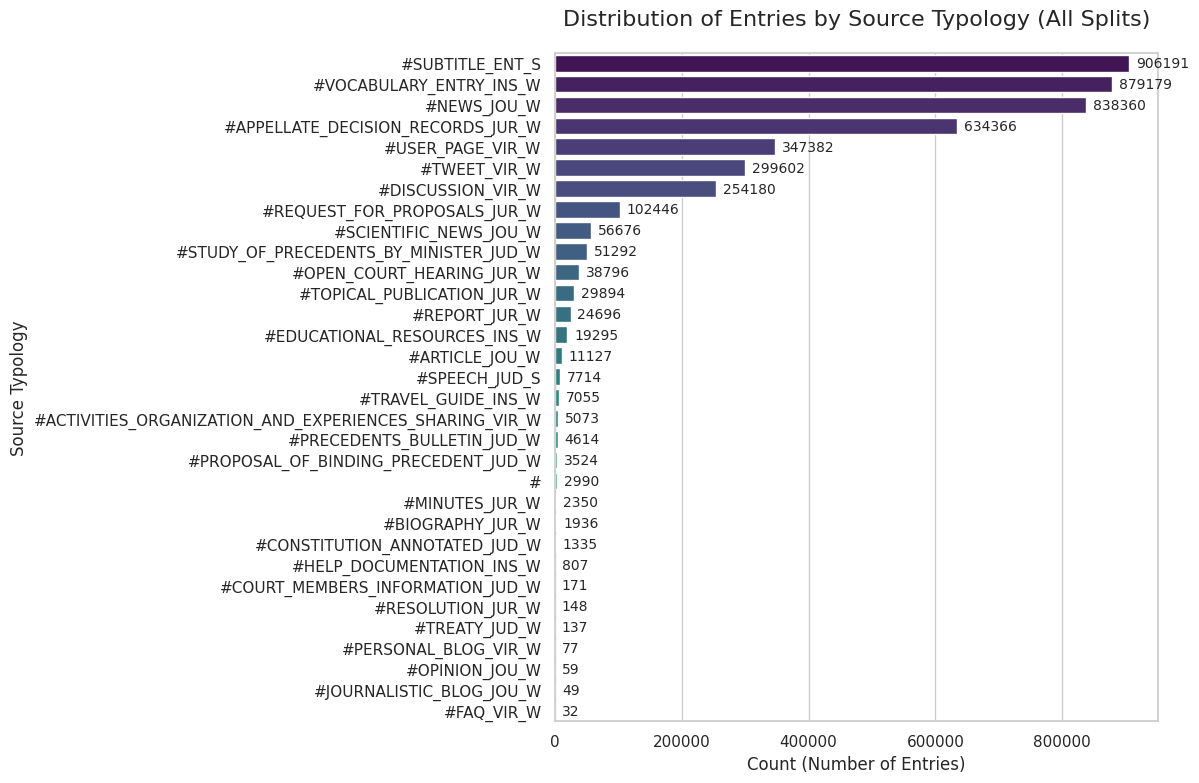


Analysis complete.


In [ ]:
# Plot the Distribution Graph

print("\nGenerating distribution plot (Countplot) for 'source_typology'...")

try:
    # Set the Seaborn theme
    sns.set_theme(style="whitegrid")

    # Create the figure.
    plt.figure(figsize=(12, 8))

    # Create the count plot
    ax = sns.countplot(
        data=df,
        y='source_typology',
        order=df['source_typology'].value_counts().index,
        palette='viridis' 
    )

    # Add titles and labels
    ax.set_title('Distribution of Entries by Source Typology (All Splits)', fontsize=16, pad=20)
    ax.set_xlabel('Count (Number of Entries)', fontsize=12)
    ax.set_ylabel('Source Typology', fontsize=12)

    # Add the exact values at the end of each bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', padding=5, fontsize=10)

    # Adjust layout to prevent labels from overlapping
    plt.tight_layout()

    # Display the plot
    plt.show()

except Exception as e:
    print(f"An error occurred while generating the plot: {e}", file=sys.stderr)

print("\nAnalysis complete.")

Note: #PROPOSAL_OF_BINDING_PRECEDENT_JUD_W seems to be a good cutoff point.